<a href="https://colab.research.google.com/github/SaloniKhare/Projects/blob/main/Zayka_AI/Zayka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Indian Food Images.zip to Indian Food Images.zip


In [2]:
import zipfile

with zipfile.ZipFile("Indian Food Images.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [3]:
!pip install tensorflow

In [4]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
print(tf.__version__)

2.19.0


In [21]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import json

# ===== PATHS =====
data_train_path = '/content/data/Indian Food Images/train'
data_val_path = '/content/data/Indian Food Images/validation'
data_test_path = '/content/data/Indian Food Images/test'

img_width = 224
img_height = 224

# ===== LOAD DATASET =====
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    image_size=(img_width, img_height),
    batch_size=32,
    shuffle=True
)
data_cat = data_train.class_names
print("Classes:", data_cat)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])
data_train = data_train.map(lambda x, y: (data_augmentation(x, training=True), y))
data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    image_size=(img_width, img_height),
    batch_size=32,
    shuffle=False
)



# Save class names
with open("class_names.json", "w") as f:
    json.dump(data_cat, f)

# ===== BUILD MODEL =====
"""model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(180,180,3)),
    layers.Conv2D(16,3,padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(data_cat),activation='softmax')
])"""

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(data_cat), activation='softmax')
])



model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# ===== TRAIN DIRECTLY USING DATASET =====
history = model.fit(
    data_train,
    validation_data=data_val,
    epochs=25,
    callbacks=[early_stop]
)

# ===== FINE TUNING =====

base_model.trainable = True

# Freeze first 100 layers (keep early layers frozen)
for layer in base_model.layers[:130]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
fine_tune_epochs = 15

history_fine = model.fit(
    data_train,
    validation_data=data_val,
    epochs=fine_tune_epochs,
    callbacks=[early_stop]
)
# ===== SAVE MODEL =====
model.save("indian_food_model.keras")
print("Model saved successfully!")

Found 1599 files belonging to 20 classes.
Classes: ['Aloo fry', 'Beetroot', 'Biryani', 'Bitter gourd', 'Butter chicken', 'Dal - Curry', 'Dosa', 'Gulab Jamun', 'Idly', 'Jalebi', 'Kebab', 'Mango Pickle', 'Palak Paneer', 'Puri', 'Rajma chawal', 'Rasmalai', 'Roti', 'Sambar', 'Samosa', 'Vada']
Found 200 files belonging to 20 classes.
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.2326 - loss: 2.6764 - val_accuracy: 0.6850 - val_loss: 1.1357
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 473ms/step - accuracy: 0.6794 - loss: 1.1273 - val_accuracy: 0.7300 - val_loss: 0.7774
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 459ms/step - accuracy: 0.7551 - loss: 0.7935 - val_accuracy: 0.7900 - val_loss: 0.6264
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 458ms/step - accuracy: 0.7990 - loss: 0.6363 - val_accuracy: 0.8000 - val_loss: 0.5816
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.8284 - loss: 0.5288 - val_accuracy: 0.8450 - val_loss: 0.4939
Epoch 6/25
50/50 ━━━━━━━━━━

In [22]:
# ===== GET FINAL VALIDATION METRICS =====
val_loss, val_acc = model.evaluate(data_val)

print("Overall Validation Accuracy:", val_acc)
print("Overall Validation Loss:", val_loss)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.8474 - loss: 0.4715
Overall Validation Accuracy: 0.8299999833106995
Overall Validation Loss: 0.5097320079803467


In [23]:
# ===== BEST VALIDATION ACCURACY =====
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print("Best Validation Accuracy:", best_val_acc)
print("Best Epoch:", best_epoch)

Best Validation Accuracy: 0.8450000286102295
Best Epoch: 5


In [24]:
data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    image_size=(img_width, img_height),
    batch_size=32,
    shuffle=False
)
test_loss, test_acc = model.evaluate(data_test)
print("Test Accuracy:", test_acc)

Found 200 files belonging to 20 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.8296 - loss: 0.5755
Test Accuracy: 0.800000011920929


{'accuracy': [0.37711068987846375, 0.6998124122619629, 0.761100709438324, 0.8161351084709167, 0.843026876449585, 0.8580362796783447, 0.8849281072616577, 0.8980612754821777], 'loss': [2.1626853942871094, 1.040416955947876, 0.76613849401474, 0.6084972023963928, 0.502657413482666, 0.4509500563144684, 0.3886892795562744, 0.3382413387298584], 'val_accuracy': [0.6850000023841858, 0.7300000190734863, 0.7900000214576721, 0.800000011920929, 0.8450000286102295, 0.824999988079071, 0.8199999928474426, 0.8399999737739563], 'val_loss': [1.135745644569397, 0.777434229850769, 0.626387357711792, 0.5815818905830383, 0.49387890100479126, 0.4918915927410126, 0.511282742023468, 0.4639049172401428]}


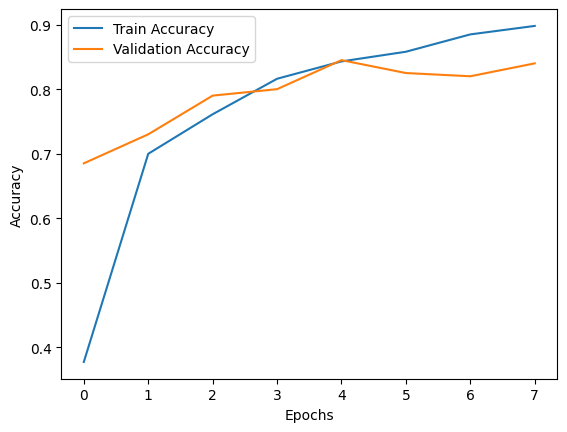

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Indian Food in image is Gulab Jamun with accuracy 12.49%


In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image
import json

print(history.history)


# ===== PLOT ACCURACY GRAPH =====
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# Load class names
with open("class_names.json", "r") as f:
    class_names = json.load(f)

# Load image
img = image.load_img("/content/data/Indian Food Images/test/Gulab Jamun/images (45).jpeg", target_size=(224, 224))
img_array = image.img_to_array(img)

# Expand dimension
img_array = np.expand_dims(img_array, axis=0)

# DO NOT rescale here (model already does preprocess_input)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "Indian Food in image is {} with accuracy {:.2f}%".format(
        class_names[np.argmax(score)],
        100 * np.max(score)
    )
)

In [26]:
from google.colab import files
files.download("indian_food_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
!pip install flask-cors

In [43]:
import io
import PIL.Image as Image
import numpy as np
import tensorflow as tf
from google.colab import output
from IPython.display import HTML, display
import base64
import json

# 1. THE PYTHON PREDICTOR FUNCTION (With Logging)
def classify_food_diagnostic(image_b64):
    try:
        # Decode image
        header, encoded = image_b64.split(",", 1)
        data = base64.b64decode(encoded)

        # Preprocess
        img = Image.open(io.BytesIO(data)).convert('RGB').resize((224, 224))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array.astype('float32')

        # Check if model exists in memory
        if 'model' not in globals():
            return {'error': 'Model variable not found in memory. Please run your training cells first.'}

        # Predict
        # Use the global 'model' from your training session
        predictions = model.predict(img_array)
        result_index = np.argmax(predictions[0])

        # Determine class names (handle data_cat or class_names)
        classes = globals().get('data_cat') or globals().get('class_names')
        if not classes:
            return {'error': 'Class names list (data_cat) not found.'}

        label = classes[result_index]
        confidence = float(np.max(predictions[0]) * 100)

        print(f"✅ Success! Predicted: {label}")
        return {'label': str(label), 'confidence': f"{confidence:.2f}%"}

    except Exception as e:
        print(f"❌ Python Error: {str(e)}")
        return {'error': str(e)}

# Register the callback
output.register_callback('notebook.classify_food_diagnostic', classify_food_diagnostic)

# 2. THE IMPROVED UI
html_ui = """
<div style="padding: 20px; border: 2px solid #e67e22; border-radius: 15px; background: #fff; font-family: sans-serif; text-align: center; max-width: 400px; margin: auto;">
    <h3 style="color: #d35400;">🍛 Indian Food Classifier</h3>

    <input type="file" id="fileInput" accept="image/*" style="display: none;">
    <label for="fileInput" style="padding: 10px 20px; background: #f39c12; color: white; border-radius: 5px; cursor: pointer; display: inline-block;">Upload Dish Photo</label>

    <div id="preview" style="margin: 15px 0;"></div>

    <button onclick="sendToPython()" id="runBtn" style="padding: 10px 20px; background: #d35400; color: white; border: none; border-radius: 5px; cursor: pointer; width: 100%;">Classify</button>

    <div id="status" style="margin-top: 15px; font-weight: bold; min-height: 50px;"></div>
</div>

<script>
async function sendToPython() {
    const fileInput = document.getElementById('fileInput');
    const statusDiv = document.getElementById('status');

    if (fileInput.files.length === 0) return alert("Please select an image!");

    statusDiv.innerHTML = "<span style='color: gray;'>Analyzing Tensors...</span>";

    const reader = new FileReader();
    reader.onload = async () => {
        const base64Image = reader.result;

        try {
            const result = await google.colab.kernel.invokeFunction('notebook.classify_food_diagnostic', [base64Image], {});
            const data = result.data['application/json'];

            if (data.error) {
                statusDiv.innerHTML = `<span style="color: red;">Error: ${data.error}</span>`;
            } else {
                statusDiv.innerHTML = `
                    <div style="background: #fdf2e9; padding: 10px; border-radius: 10px;">
                        <span style="font-size: 1.4em; color: #e67e22;">${data.label}</span><br>
                        <span style="color: #7f8c8d;">Match: ${data.confidence}</span>
                    </div>`;
            }
        } catch (err) {
            statusDiv.innerHTML = `<span style="color: red;"></span>`;
            console.error(err);
        }
    };
    reader.readAsDataURL(fileInput.files[0]);
}

document.getElementById('fileInput').onchange = e => {
    const reader = new FileReader();
    reader.onload = () => {
        document.getElementById('preview').innerHTML = `<img src="${reader.result}" style="max-width: 100%; border-radius: 10px; height: 150px;">`;
    }
    reader.readAsDataURL(e.target.files[0]);
}
</script>
"""
display(HTML(html_ui))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
✅ Success! Predicted: Samosa
